# Assignment 7: Exploring Specialized Neural Network Architectures
# Building Convolutional Neural Networks for Image Classification

**Name:** [Your Name Here]

**Date:** [Date]

---

## Setup: Install and Load Libraries

In [22]:
pip install tensorflow matplotlib numpy pandas

Note: you may need to restart the kernel to use updated packages.


In [23]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load and Explore MNIST Dataset

In [24]:
# Load MNIST dataset
print("Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()


print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Class labels: {np.unique(y_train)}")

Loading MNIST dataset...
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]


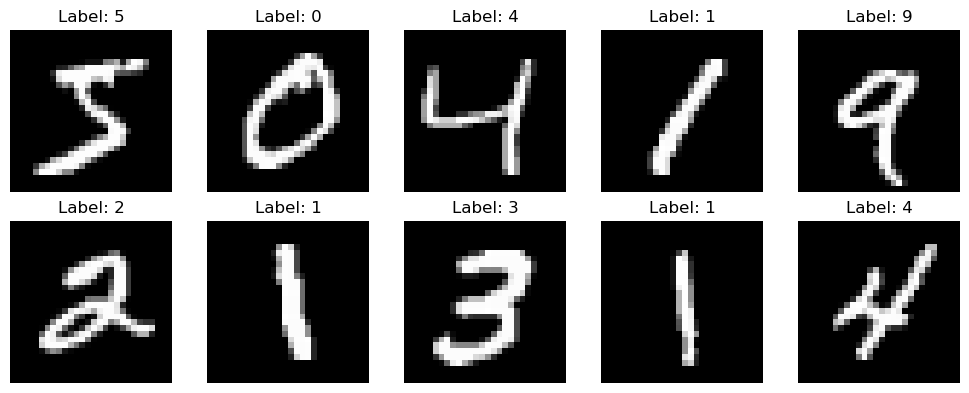

In [25]:
# Visualize sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Prepare Data for CNN

In [26]:
# Reshape to add channel dimension (samples, height, width, channels)
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype('float32')

# Normalize pixel values to 0-1 range
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

print("\n" + "="*80)
print("DATA PREPARED FOR CNN")
print("="*80)
print(f"Training data shape: {X_train_cnn.shape}")
print(f"Test data shape: {X_test_cnn.shape}")
print(f"Pixel value range: [{X_train_cnn.min():.1f}, {X_train_cnn.max():.1f}]")
print("="*80)


DATA PREPARED FOR CNN
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)
Pixel value range: [0.0, 1.0]


---
## Step 2: Build and Train a Baseline CNN

In [27]:
# TODO: Build your baseline CNN here
# Architecture:
# - Conv2D layer: 32 filters, 3x3 kernel, ReLU activation, input_shape=(28, 28, 1)
# - MaxPooling2D: 2x2 pool size
# - Conv2D layer: 64 filters, 3x3 kernel, ReLU activation
# - MaxPooling2D: 2x2 pool size
# - Flatten layer
# - Dense layer: 128 nodes, ReLU activation
# - Output layer: 10 nodes (digits 0-9), softmax activation

baseline_cnn = keras.Sequential([layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),layers.MaxPooling2D((2,2)),
layers.Conv2D(64, (3,3), activation='relu'),layers.MaxPooling2D((2,2)),
layers.Flatten(),layers.Dense(128, activation='relu'),
layers.Dense(10, activation='softmax')
    # TODO: Add layers here
])

# TODO: Compile the model
# Use Adam optimizer and sparse_categorical_crossentropy loss
baseline_cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)


# Display model architecture
baseline_cnn.summary()

c:\Users\kgmad\anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Record training time
print("\nTraining baseline CNN...")
start_time = time.time()

# TODO: Fit the model and store history
history = baseline_cnn.fit(X_train_cnn, y_train,epochs=10,batch_size=128,
validation_split=0.2,verbose=1) # Replace with actual model fitting

baseline_time = time.time() - start_time

# TODO: Evaluate on test set
baseline_test_loss, baseline_test_acc = baseline_cnn.evaluate(X_test_cnn, y_test)  # Replace with actual evaluation

print("\n" + "="*80)
print("BASELINE CNN RESULTS")
print("="*80)
# Print final training accuracy, validation accuracy, test accuracy, training time
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.4f}")
print(f"Training Time: {baseline_time:.2f} seconds")
print("="*80)


Training baseline CNN...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9265 - loss: 0.2463 - val_accuracy: 0.9781 - val_loss: 0.0758
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9797 - loss: 0.0651 - val_accuracy: 0.9855 - val_loss: 0.0535
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9863 - loss: 0.0449 - val_accuracy: 0.9858 - val_loss: 0.0464
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9889 - loss: 0.0343 - val_accuracy: 0.9872 - val_loss: 0.0395
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9918 - loss: 0.0266 - val_accuracy: 0.9840 - val_loss: 0.0498
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9930 - loss: 0.0215 - val_accuracy: 0.9874 - val_loss: 0.0415
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9946 - loss: 0.0171 - val_accuracy: 0.9894 - val_loss: 0.0374
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9957

---
## Step 3: Experiment with Filter Counts

In [29]:
# TODO: Build and train CNN with FEWER filters (16, 32)
# Keep all other architecture elements the same as baseline
fewer_cnn=keras.Sequential([layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
 layers.MaxPooling2D((2,2)),layers.Conv2D(32, (3,3), activation='relu'),
layers.MaxPooling2D((2,2)),layers.Flatten(),
layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')])
print("Training CNN with fewer filters (16, 32)...")
# TODO: Build, compile, and train model
# Record validation accuracy
fewer_cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',
metrics=['accuracy'])
history_fewer = fewer_cnn.fit(X_train_cnn, y_train, epochs=10, validation_split=0.2)

Training CNN with fewer filters (16, 32)...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9422 - loss: 0.1871 - val_accuracy: 0.9785 - val_loss: 0.0742
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9816 - loss: 0.0596 - val_accuracy: 0.9839 - val_loss: 0.0563
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9871 - loss: 0.0397 - val_accuracy: 0.9850 - val_loss: 0.0539
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9903 - loss: 0.0302 - val_accuracy: 0.9855 - val_loss: 0.0500
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9925 - loss: 0.0231 - val_accuracy: 0.9867 - val_loss: 0.0456
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9940 - loss: 0.0171 - val_accuracy: 0.9898 - val_loss: 0.0407
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9955 - loss: 0.0133 - val_accuracy: 0.9856 - val_loss: 0.0533
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4

In [30]:
# TODO: Build and train CNN with MORE filters (64, 128)
# Keep all other architecture elements the same as baseline
more_cnn = keras.Sequential([layers.Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1)),layers.MaxPooling2D((2,2)),
layers.Conv2D(128, (3,3), activation='relu'),layers.MaxPooling2D((2,2)),
layers.Flatten(),layers.Dense(128, activation='relu'),
layers.Dense(10, activation='softmax')])
print("Training CNN with more filters (64, 128)...")
# TODO: Build, compile, and train model
more_cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
history_more = more_cnn.fit(X_train_cnn, y_train, epochs=10, validation_split=0.2)
# Record validation accuracy

Training CNN with more filters (64, 128)...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9608 - loss: 0.1274 - val_accuracy: 0.9854 - val_loss: 0.0529
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9865 - loss: 0.0417 - val_accuracy: 0.9872 - val_loss: 0.0428
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9915 - loss: 0.0278 - val_accuracy: 0.9892 - val_loss: 0.0392
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9934 - loss: 0.0196 - val_accuracy: 0.9884 - val_loss: 0.0421
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9948 - loss: 0.0151 - val_accuracy: 0.9898 - val_loss: 0.0423
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9958 - loss: 0.0121 - val_accuracy: 0.9887 - val_loss: 0.0452
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9967 - loss: 0.0095 - val_accuracy: 0.9879 - val_loss: 0.0563
Epoch 8/10
1500/1500 ━━━━━━━━━━━

### Analysis: Filter Count Effects

**TODO: Write 2-3 sentences answering:**
- How does increasing filter count affect performance?
- At what point do you see diminishing returns or overfitting?

[Increasing the filter countm you would think usually would lead to a higher accuracy. However, in this case, I got more a higher accuracy amount in my baseline testing than when I added more filters. I started seeing diminishing returns at (64,128)]

---
## Step 4: Experiment with Kernel Sizes

In [31]:
# TODO: Build and train CNN with MEDIUM kernels (5x5 for both layers)
# Keep filter counts at baseline (32, 64)
cnn_5x5 = keras.Sequential([layers.Conv2D(32, (5,5), activation='relu', input_shape=(28,28,1)),
layers.MaxPooling2D((2,2)),
layers.Conv2D(64, (5,5), activation='relu'),layers.MaxPooling2D((2,2)),
layers.Flatten(), layers.Dense(128, activation='relu'),
 layers.Dense(10, activation='softmax')])
print("Training CNN with 5x5 kernels...")
# TODO: Build, compile, and train model
cnn_5x5.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])
# Record validation accuracy
history_5x5 = cnn_5x5.fit(X_train_cnn, y_train, epochs=10, validation_split=0.2)

Training CNN with 5x5 kernels...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9575 - loss: 0.1354 - val_accuracy: 0.9862 - val_loss: 0.0454
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9869 - loss: 0.0428 - val_accuracy: 0.9859 - val_loss: 0.0473
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9913 - loss: 0.0290 - val_accuracy: 0.9885 - val_loss: 0.0401
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9932 - loss: 0.0222 - val_accuracy: 0.9893 - val_loss: 0.0389
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9944 - loss: 0.0181 - val_accuracy: 0.9878 - val_loss: 0.0438
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9958 - loss: 0.0137 - val_accuracy: 0.9895 - val_loss: 0.0405
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9963 - loss: 0.0112 - val_accuracy: 0.9912 - val_loss: 0.0368
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/ste

In [32]:
# TODO: Build and train CNN with MIXED kernels (5x5 first layer, 3x3 second layer)
# Keep filter counts at baseline (32, 64)
cnn_mixed = keras.Sequential([layers.Conv2D(32, (5,5), activation='relu', input_shape=(28,28,1)),
layers.MaxPooling2D((2,2)),layers.Conv2D(64, (3,3), activation='relu'),
layers.MaxPooling2D((2,2)),layers.Flatten(),
layers.Dense(128, activation='relu'),
layers.Dense(10, activation='softmax')])
print("Training CNN with mixed kernels (5x5, 3x3)...")
# TODO: Build, compile, and train model
cnn_mixed.compile(optimizer='adam',loss='sparse_categorical_crossentropy',
metrics=['accuracy'])
# Record validation accuracy
history_mixed = cnn_mixed.fit(X_train_cnn, y_train, epochs=10, validation_split=0.2)

Training CNN with mixed kernels (5x5, 3x3)...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9592 - loss: 0.1309 - val_accuracy: 0.9824 - val_loss: 0.0569
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9869 - loss: 0.0439 - val_accuracy: 0.9848 - val_loss: 0.0526
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9901 - loss: 0.0310 - val_accuracy: 0.9894 - val_loss: 0.0383
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9928 - loss: 0.0219 - val_accuracy: 0.9887 - val_loss: 0.0366
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9945 - loss: 0.0170 - val_accuracy: 0.9894 - val_loss: 0.0372
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9955 - loss: 0.0134 - val_accuracy: 0.9910 - val_loss: 0.0339
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9962 - loss: 0.0110 - val_accuracy: 0.9889 - val_loss: 0.0443
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 

### Analysis: Kernel Size Effects

**TODO: Write 2-3 sentences answering:**
- How does kernel size affect what the network learns?
- Which kernel configuration performed best and why might that be?

[Kernel size affects how far within the image the filter will examine. The size specifically will determine if the filter will capyure a larger picture or more finer details in a smaller region. I think the 3x3 performed best because it gave a higher accuracy. ]

---
## Step 5: Train Your Best Architecture and Visualize Learning

In [33]:
# TODO: Based on your experiments, build your best-performing CNN architecture
# Train for 15 epochs with 20% validation split
best_cnn = keras.Sequential([layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
 layers.MaxPooling2D((2,2)),layers.Conv2D(64, (3,3), activation='relu'),
layers.MaxPooling2D((2,2)),layers.Flatten(),
layers.Dense(128, activation='relu'),
layers.Dense(10, activation='softmax')])
print("Training best CNN architecture...")
best_cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',
metrics=['accuracy'])
start_time = time.time()

# TODO: Build, compile, and train your best model
# Store the training history
best_history = best_cnn.fit(
X_train_cnn, y_train,
epochs=15,
validation_split=0.2)
best_cnn_time = time.time() - start_time

# TODO: Evaluate on test set
best_test_loss, best_test_acc = best_cnn.evaluate(X_test_cnn, y_test)

Training best CNN architecture...
Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9555 - loss: 0.1457 - val_accuracy: 0.9832 - val_loss: 0.0568
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9856 - loss: 0.0464 - val_accuracy: 0.9838 - val_loss: 0.0526
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9902 - loss: 0.0314 - val_accuracy: 0.9871 - val_loss: 0.0385
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9923 - loss: 0.0225 - val_accuracy: 0.9887 - val_loss: 0.0407
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9945 - loss: 0.0165 - val_accuracy: 0.9889 - val_loss: 0.0427
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9961 - loss: 0.0121 - val_accuracy: 0.9872 - val_loss: 0.0530
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9969 - loss: 0.0101 - val_accuracy: 0.9887 - val_loss: 0.0465
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/ste

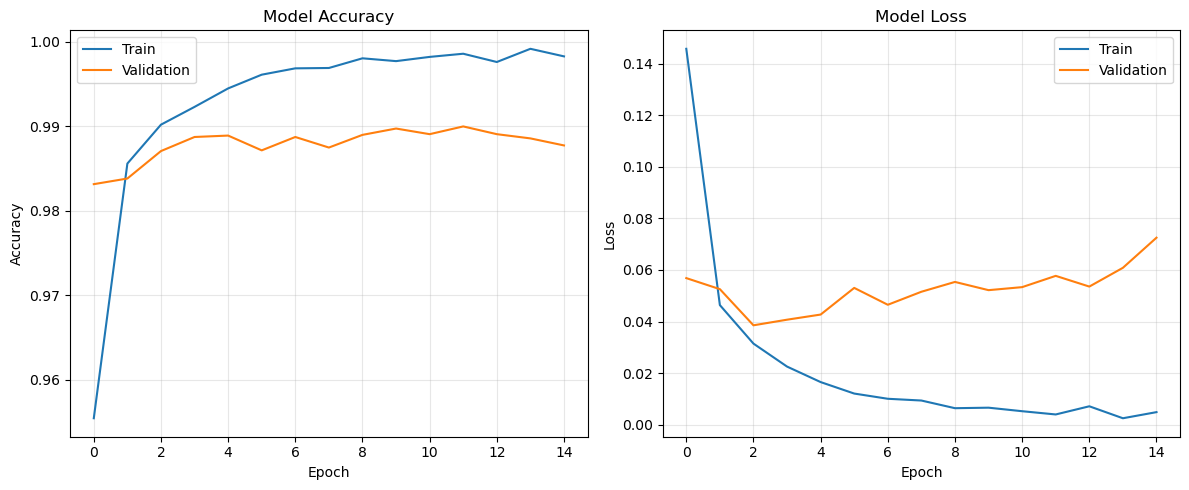

In [34]:
# TODO: Create accuracy plot (training vs validation accuracy over epochs)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
# TODO: Plot training and validation accuracy
plt.plot(best_history.history['accuracy'], label='Train')
plt.plot(best_history.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
# TODO: Plot training and validation loss
plt.plot(best_history.history['loss'], label='Train')
plt.plot(best_history.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 6: Compare Against Feedforward Network

In [35]:
# Prepare data for feedforward network (flatten images)
X_train_flat = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test_flat = X_test.reshape(-1, 784).astype('float32') / 255.0

print(f"Flattened training data shape: {X_train_flat.shape}")
print(f"Flattened test data shape: {X_test_flat.shape}")

Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)


In [36]:
# TODO: Build feedforward network
# Architecture:
# - Input: 784 features (flattened 28x28 image)
# - Dense layer: 128 nodes, ReLU activation
# - Dense layer: 64 nodes, ReLU activation
# - Output layer: 10 nodes, softmax activation

feedforward_nn = keras.Sequential([
layers.Dense(128, activation='relu', input_shape=(784,)),
layers.Dense(64, activation='relu'),
layers.Dense(10, activation='softmax')   # TODO: Add layers here
])

# TODO: Compile the model
feedforward_nn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',
metrics=['accuracy'])
feedforward_nn.summary()

c:\Users\kgmad\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Record training time
print("Training feedforward network...")
start_time = time.time()

# TODO: Train feedforward network for 10 epochs
# Fit the model
feedforward_nn.fit(X_train_flat, y_train,epochs=10,validation_split=0.2)

# Record training time
feedforward_time = time.time() - start_time

# TODO: Evaluate on test set
feedforward_loss,feedforward_acc=feedforward_nn.evaluate(X_test_flat, y_test)


Training feedforward network...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9219 - loss: 0.2624 - val_accuracy: 0.9582 - val_loss: 0.1428
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9666 - loss: 0.1105 - val_accuracy: 0.9672 - val_loss: 0.1105
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9764 - loss: 0.0757 - val_accuracy: 0.9707 - val_loss: 0.0971
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9818 - loss: 0.0567 - val_accuracy: 0.9728 - val_loss: 0.0932
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9866 - loss: 0.0426 - val_accuracy: 0.9736 - val_loss: 0.0980
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9884 - loss: 0.0358 - val_accuracy: 0.9728 - val_loss: 0.1013
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9908 - loss: 0.0280 - val_accuracy: 0.9717 - val_loss: 0.1125
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - ac

In [38]:
# TODO: Create comparison table

comparison_data = {
    'Model': ['Baseline CNN', 'Best CNN', 'Feedforward NN'],
    'Architecture': [ 
        '32-64 filters, 3x3 kernels','Optimized CNN (same structure)', 'Dense 128-64'
    ],
    'Test Accuracy': [
        baseline_test_acc,best_test_acc,
        feedforward_acc,
    ],
    'Training Time (s)': [
        # TODO: Fill in training times
        baseline_time,
        best_cnn_time,
        feedforward_time
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


MODEL COMPARISON
         Model                   Architecture  Test Accuracy  Training Time (s)
  Baseline CNN     32-64 filters, 3x3 kernels         0.9916          59.125672
      Best CNN Optimized CNN (same structure)         0.9886         138.302406
Feedforward NN                   Dense 128-64         0.9736          25.111884


### Analysis: CNN vs Feedforward Network

**TODO: Write 2-3 sentences answering:**
- How does your best CNN compare to the feedforward network on image data?
- Why does the CNN's spatial awareness lead to better performance than treating pixels as independent features?

[My best CNN had a higher test accuracy than the feedfoward, but my best CNN also had a much longer training time. The feedforwafard network evaluates each pixel of an image independently. This makes the network lose more details in the image.]

---
## Step 7: Reflect on Specialized Architectures for Your Final Project

### Final Project Application

**TODO: Write 3-4 sentences answering:**
- Based on your Unit 9 final project proposal, would CNNs or RNNs enhance your project? Why or why not?
- If your project uses tabular data (customer demographics, transaction records), explain why feedforward networks or traditional ML models remain appropriate.
- If your project could benefit from specialized architectures (images, time series, text), describe specifically how CNNs or RNNs would improve your solution compared to the approaches you've planned.

[As of right now, I do not see muself using the CNN or RNNs to enhance my project, because I do not have images in my data set. If i were to add spatial or sequential data that these machines are used for, then I may reconsider.My project uses tabular data, so ML models or neural networks are more appropriate for me.CNNs or RNNs would improve my project like i previosuly mentioned if i had images for my data sets.]

---
## Submission Checklist

Before submitting, ensure you have:
- [ ] Built and trained baseline CNN (2 conv layers)
- [ ] Conducted at least 3 architecture experiments (filter counts and kernel sizes)
- [ ] Trained best CNN architecture for 15 epochs
- [ ] Created accuracy and loss plots for best model
- [ ] Built and trained feedforward network for comparison
- [ ] Created comparison table with all models
- [ ] Answered all analysis questions in Markdown cells
- [ ] Written reflection on final project application
- [ ] Pushed code to GitHub repository
- [ ] Submitted GitHub repository link to assignment

---
## Step 8: Submit Your Work
Push to GitHub:
```bash
git add .
git commit -m 'completed CNN architecture assignment'
git push
```

Submit your GitHub repository link on the course platform.